# Simulation: Predicting future winners

🎯 **Goal**: Simulate many possible Taskmaster series and estimate win probabilities

In Notebook 3, I built a model to predict final outcomes from a given point in the series.
However, point predictions don’t capture uncertainty or variability in performance.

To address this, I move from prediction to simulation - modelling how a series could play out many different ways.

**Approach**:

- Collapse episode-level data into per-contestant scoring behaviour (mean + standard deviation)
- Simulate full series by sampling episode scores from these distributions
- Repeat simulation 1,000 times to generate a distribution of outcomes
- Calculate win probability for each contestant
- Compare results with archetypes to interpret performance patterns

### Executive Summary

- Simulated 1,000 versions of Series 5 using per-contestant scoring distributions
- 🏆 Bob Mortimer emerges as the favourite, winning 56% of simulations
- 💪 Mark Watson (23%), Aisling Bea (12%), and Sally Phillips (9%) win less frequently but remain competitive
- 💔 Nish Kumar does not win in any simulations, reflecting a significantly lower average performance

**Key insight**:

*Winning is driven by both average performance and consistency - stronger contestants win more often, but variability allows for alternative outcomes.*

Additionally:

*Archetypes correlate with outcomes: “Strong & Consistent” performers (aka The Chaos Enginer) dominate, while “Strugglers” (aka The Silent Assassin) rarely win. However, archetype alone is not sufficient - absolute scoring level remains critical.*

### Imports

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

PROCESSED_PATH = DATA_DIR / "processed"

### Load data

In [4]:
snapshot_df = pd.read_csv(PROCESSED_PATH / "snapshot_df.csv")

snapshot_df.shape

(730, 18)

In [5]:
snapshot_df.columns.to_list()

['episode',
 'episode_label',
 'contestant',
 'episode_score',
 'series_id',
 'episode_in_series',
 'cumulative_score',
 'mean_score_so_far',
 'std_score_so_far',
 'recent_avg_score',
 'momentum',
 'episodes_played',
 'final_score',
 'total_episodes',
 'final_rank',
 'won_series',
 'remaining_episodes',
 'current_rank']

In [6]:
snapshot_df.head()

,episode,episode_label,contestant,episode_score,series_id,episode_in_series,cumulative_score,mean_score_so_far,std_score_so_far,recent_avg_score,momentum,episodes_played,final_score,total_episodes,final_rank,won_series,remaining_episodes,current_rank
0,1,Melon buffet.,Frank Skinner,19,1,1,19,19.0,0.0,19.0,0.0,1,93,6,2.0,0,5,1.0
1,1,Melon buffet.,Josh Widdicombe,13,1,1,13,13.0,0.0,13.0,0.0,1,94,6,1.0,1,5,4.0
2,1,Melon buffet.,Roisin Conaty,7,1,1,7,7.0,0.0,7.0,0.0,1,68,6,5.0,0,5,5.0
3,1,Melon buffet.,Romesh Ranganathan,19,1,1,19,19.0,0.0,19.0,0.0,1,93,6,2.0,0,5,1.0
4,1,Melon buffet.,Tim Key,17,1,1,17,17.0,0.0,17.0,0.0,1,88,6,4.0,0,5,3.0


In [7]:
snapshot_df.duplicated(
    subset=["series_id", "contestant", "episode_in_series"]
).sum()

np.int64(0)

In [8]:
snapshot_df.groupby(["series_id", "contestant"])["episode_in_series"].nunique().describe()

count    105.000000
mean       6.952381
std        3.609232
min        1.000000
25%        5.000000
50%        8.000000
75%       10.000000
max       10.000000
Name: episode_in_series, dtype: float64

In [9]:
snapshot_df[
    (snapshot_df["series_id"] == snapshot_df["series_id"].iloc[0]) &
    (snapshot_df["contestant"] == snapshot_df["contestant"].iloc[0])
]

,episode,episode_label,contestant,episode_score,series_id,episode_in_series,cumulative_score,mean_score_so_far,std_score_so_far,recent_avg_score,momentum,episodes_played,final_score,total_episodes,final_rank,won_series,remaining_episodes,current_rank
0,1,Melon buffet.,Frank Skinner,19,1,1,19,19.000000,0.000000,19.0,0.000000,1,93,6,2.0,0,5,1.0
5,2,The pie whisperer.,Frank Skinner,9,1,2,28,14.000000,7.071068,14.0,0.000000,2,93,6,2.0,0,4,4.0
10,3,The poet and the egg.,Frank Skinner,15,1,3,43,14.333333,5.033223,12.0,-2.333333,3,93,6,2.0,0,3,4.0
15,4,Down an octave.,Frank Skinner,14,1,4,57,14.250000,4.112988,14.5,0.250000,4,93,6,2.0,0,2,4.0
20,5,Little denim shorts.,Frank Skinner,20,1,5,77,15.400000,4.393177,17.0,1.600000,5,93,6,2.0,0,1,3.0
25,6,The last supper.,Frank Skinner,16,1,6,93,15.500000,3.937004,18.0,2.500000,6,93,6,2.0,0,0,2.0


## Structure data

In [11]:
# Create simplified episode view
episode_df = snapshot_df[["series_id", "contestant", "episode_in_series", "episode_score"]].drop_duplicates().copy()

In [12]:
# Build contestant summary stats
contestant_stats = (
    episode_df.groupby(["series_id", "contestant"])["episode_score"]
    .agg(["count", "mean", "std"])
    .reset_index()
    .rename(columns={
        "count": "n_episodes_observed",
        "mean": "episode_score_mean",
        "std": "episode_score_std"
    })
)

contestant_stats.head()

,series_id,contestant,n_episodes_observed,episode_score_mean,episode_score_std
0,1,Frank Skinner,6,15.500000,3.937004
1,1,Josh Widdicombe,6,15.666667,4.412105
2,1,Roisin Conaty,6,11.333333,5.316641
3,1,Romesh Ranganathan,6,15.500000,4.460942
4,1,Tim Key,6,14.666667,4.082483


In [14]:
contestant_stats.groupby("series_id")["contestant"].nunique()

series_id
1     5
2     5
3     5
4     5
5     5
6     5
7     5
8     5
9     5
10    5
11    5
12    5
13    5
14    5
15    5
16    5
17    5
18    5
19    5
20    5
21    5
Name: contestant, dtype: int64

In [15]:
contestant_stats["episode_score_std"].describe()

count    85.000000
mean      3.964409
std       1.302512
min       0.000000
25%       3.212822
50%       4.082483
75%       4.737557
max       8.074652
Name: episode_score_std, dtype: float64

## Simulate an existing series

In [20]:
series_to_simulate = 5

series_stats = contestant_stats[contestant_stats["series_id"] == series_to_simulate].copy()

series_stats

,series_id,contestant,n_episodes_observed,episode_score_mean,episode_score_std
20,5,Aisling Bea,8,15.750,4.166190
21,5,Bob Mortimer,8,17.250,2.052873
22,5,Mark Watson,8,16.250,3.955105
23,5,Nish Kumar,8,13.375,2.386719
24,5,Sally Phillips,8,16.250,2.052873


In [21]:
n_episodes = episode_df[episode_df["series_id"] == series_to_simulate]["episode_in_series"].nunique()

n_episodes

8

In [31]:
episode_df["episode_score"].max()

np.int64(30)

In [39]:
def simulate_one_series(series_stats, n_episodes, random_state=None):
    """
    Simulate one full Taskmaster series.

    Parameters:
    - series_stats: dataframe with one row per contestant
      (must include mean + std of episode_score)
    - n_episodes: number of episodes to simulate
    - random_state: seed for reproducibility (optional)
    """

    # Create random number generator
    rng = np.random.default_rng(random_state)

    results = []

    # Loop over each contestant
    for _, row in series_stats.iterrows():
        # Extract contestant name and score stats
        contestant = row["contestant"]
        mean_score = row["episode_score_mean"]
        std_score = row["episode_score_std"]

        # Simulate scores for each episode
        simulated_scores = rng.normal(
            loc=mean_score,     # average performance
            scale=std_score,    # variability in performance
            size=n_episodes     # number of episodes to simulate
            )

        # Clean up values (e.g. no negative scores)
        simulated_scores = np.clip(simulated_scores, 0, 35) # historical max = 30

        # Total series score
        total_score = simulated_scores.sum()

        # Store results
        results.append({
            "contestant": contestant,
            "simulated_total_score": total_score
        })

    # Convert results to dataframe
    results_df = pd.DataFrame(results)

    # Rank contestants by simulated total score
    results_df = results_df.sort_values(
        "simulated_total_score", ascending=False
    ).reset_index(drop=True)

    return results_df

In [40]:
sim_result = simulate_one_series(series_stats, n_episodes, random_state=42)
sim_result

,contestant,simulated_total_score
0,Bob Mortimer,141.261673
1,Mark Watson,131.742669
2,Sally Phillips,128.544398
3,Aisling Bea,115.643400
4,Nish Kumar,113.434781


In [43]:
# ---- Comparison of expected vs simulated results ----

# Expected total = mean * number of episodes
series_stats["expected_total"] = (
    series_stats["episode_score_mean"] * n_episodes
)

# Merge with one simulation result
comparison_df = series_stats.merge(
    sim_result,
    on="contestant"
)[[
    "contestant",
    "episode_score_mean",
    "expected_total",
    "simulated_total_score"
]]

comparison_df = comparison_df.sort_values(
    "expected_total", ascending=False
)

In [42]:
actual_totals = (
    snapshot_df[snapshot_df["series_id"] == series_to_simulate]
    .groupby("contestant")["final_score"]
    .max()
    .reset_index()
    .rename(columns={"final_score": "actual_total"})
)

comparison_df = comparison_df.merge(
    actual_totals,
    on="contestant",
    how="left"
)

comparison_df

,contestant,episode_score_mean,expected_total,simulated_total_score,actual_total
0,Bob Mortimer,17.250,138.0,141.261673,138
1,Mark Watson,16.250,130.0,131.742669,130
2,Sally Phillips,16.250,130.0,128.544398,130
3,Aisling Bea,15.750,126.0,115.643400,126
4,Nish Kumar,13.375,107.0,113.434781,107


### 🙋‍♀️ Simulation sanity check

Before scaling up to many simulations, I validated that a single simulated series produced realistic outputs.

- Simulated episode scores are centred around each contestant’s historical mean, with variation aligned to their observed standard deviation
- Total simulated scores closely match expected values (mean × number of episodes), with reasonable random variation
- Resulting rankings are directionally consistent with actual series outcomes (e.g. stronger contestants tend to win, but with some variability)

This gave confidence that the simulation is behaving as intended before running it at scale.

## Run many simulations

A single simulated series gives one possible outcome, but results vary due to randomness.

To understand the range of possible outcomes, I repeat the simulation 1,000 times using the same contestants and scoring behaviour. Each run represents a different plausible version of the series.

Aggregating across these simulations allows me to estimate how often each contestant would win, given their typical performance and variability.

In [48]:
def simulate_many_series(series_stats, n_episodes, n_simulations=1000):
    """
    Simulate the sameTaskmaster series multiple times.

    Parameters:
     - series_stats: one row per contestant with mean/std stats
    - n_episodes: number of episodes in the series
    - n_simulations: how many full series to simulate

    Returns:
    - dataframe containing every contestant's result in every simulation
    """

    all_simulations = []

    for sim_id in range(n_simulations):

        sim_result = simulate_one_series(
            series_stats=series_stats,
            n_episodes=n_episodes,
            random_state=sim_id # Use sim number as seed for reproducibility
        )

        # Create new column to track which simulation this is
        sim_result["simulation"] = sim_id

        # Create rank within simulated series
        sim_result["simulated_rank"] = sim_result["simulated_total_score"].rank(
            method="min", ascending=False
        ).astype(int)

        # Store results
        all_simulations.append(sim_result)

    # Combine all simulations into one dataframe
    all_simulations_df = pd.concat(all_simulations, ignore_index=True)

    return all_simulations_df

In [50]:
simulations_df = simulate_many_series(
    series_stats,
    n_episodes,
    n_simulations=1000
    )

simulations_df.head(10)

,contestant,simulated_total_score,simulation,simulated_rank
0,Aisling Bea,137.731804,0,1
1,Mark Watson,136.003173,0,2
2,Sally Phillips,135.020540,0,3
3,Bob Mortimer,123.479815,0,4
4,Nish Kumar,101.930449,0,5
5,Bob Mortimer,138.926262,1,1
6,Mark Watson,132.932679,1,2
7,Aisling Bea,132.625816,1,3
8,Sally Phillips,132.236256,1,4
9,Nish Kumar,98.025088,1,5


In [51]:
simulations_df.shape

(5000, 4)

In [54]:
simulations_df["simulation"].nunique()

1000

### Calculate win probabilities

In [55]:
# keep only rows where contestant finished rank 1
# count how many times each contestant did that

win_probabilities = (
    simulations_df[simulations_df["simulated_rank"] == 1]
    .groupby("contestant")
    .size()
    .reset_index(name="wins")
)

# Convert wins into probabilities
win_probabilities["win_probability"] = (
    win_probabilities["wins"] / simulations_df["simulation"].nunique()
)

win_probabilities = win_probabilities.sort_values(
    "win_probability", ascending=False
    ).reset_index(drop=True)

win_probabilities

,contestant,wins,win_probability
0,Bob Mortimer,564,0.564
1,Mark Watson,226,0.226
2,Aisling Bea,120,0.120
3,Sally Phillips,90,0.090


In [56]:
# Make sure all contestants have a win probability (even if 0)
all_contestants = pd.DataFrame({
    "contestant": series_stats["contestant"].unique()})

# Merge with win probabilities where > 0
win_probabilities = all_contestants.merge(
    win_probabilities,
    on="contestant",
    how="left"
)

# Fill missing values with 0 (for contestants who never won in simulations)
win_probabilities["wins"] = win_probabilities["wins"].fillna(0)
win_probabilities["win_probability"] = win_probabilities["win_probability"].fillna(0)

win_probabilities = win_probabilities.sort_values(
    "win_probability", ascending=False
    ).reset_index(drop=True)

win_probabilities

,contestant,wins,win_probability
0,Bob Mortimer,564.0,0.564
1,Mark Watson,226.0,0.226
2,Aisling Bea,120.0,0.120
3,Sally Phillips,90.0,0.090
4,Nish Kumar,0.0,0.000


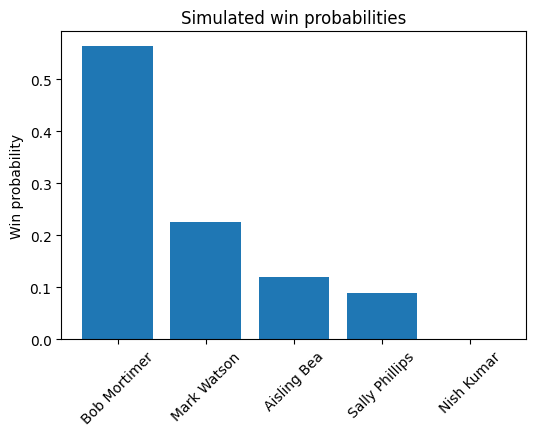

In [57]:
plt.figure(figsize=(6, 4))
plt.bar(win_probabilities["contestant"], win_probabilities["win_probability"])
plt.xticks(rotation=45)
plt.ylabel("Win probability")
plt.title("Simulated win probabilities")
plt.show()

### 🏁 Simulated win probabilities (Series 5)

Across 1,000 simulated series, Bob Mortimer emerges as the most likely winner, with a 56% win probability. However, he does not dominate entirely - Mark Watson and others still win a meaningful proportion of simulations.

This reflects the role of variability in performance: even strong contestants do not win every time, and less consistent contestants can occasionally outperform expectations.

At the lower end, Nish Kumar does not win in any simulations, indicating that his average performance is too low to overcome the competition even under favourable variance. 💔

Overall, the simulation highlights how both average performance and consistency contribute to success.

In [61]:
archetypes_df = pd.read_csv(PROCESSED_PATH / "archetypes.csv")

archetypes_df.columns.to_list()

['series_id', 'contestant', 'cluster', 'archetype']

In [67]:
archetypes_df["archetype_name"] = archetypes_df["cluster"].map(cluster_name_map)

win_with_archetypes = win_probabilities.merge(
    archetypes_df,
    on="contestant",
    how="left"
)

cluster_name_map = {
    0: "The Early Leader",
    1: "The Chaos Engine",
    2: "The Late Bloomer",
    3: "The Silent Assassin",
    4: "The Underdog"
}

win_with_archetypes.sort_values("win_probability", ascending=False)

,contestant,wins,win_probability,series_id,cluster,archetype,archetype_name
0,Bob Mortimer,564.0,0.564,5,1,Strong & Consistent,The Chaos Engine
1,Mark Watson,226.0,0.226,5,2,Solid but Fading,The Late Bloomer
2,Aisling Bea,120.0,0.120,5,2,Solid but Fading,The Late Bloomer
3,Sally Phillips,90.0,0.090,5,1,Strong & Consistent,The Chaos Engine
4,Nish Kumar,0.0,0.000,5,3,Strugglers,The Silent Assassin


In [68]:
win_with_archetypes.groupby("archetype_name")["win_probability"].mean()

archetype_name
The Chaos Engine       0.327
The Late Bloomer       0.173
The Silent Assassin    0.000
Name: win_probability, dtype: float64

#### 🙋‍♀️ Win Probabilities vs Archetypes

To better understand what drives success, I compared simulated win probabilities with previously defined contestant archetypes.

Strong and consistent performers tend to dominate, with the highest win probabilities. More volatile or declining performers remain competitive but win less frequently, while lower-performing contestants rarely win at all.

However, archetype alone does not fully determine outcomes. Contestants within the same archetype can have very different win probabilities depending on their overall scoring level. For example, both Bob Mortimer and Sally Phillips are classified as “Strong & Consistent”, yet Bob wins far more often due to a higher average score.

This suggests that both *consistency* and *absolute performance level* are key drivers of success.

## 💡 Conclusion

This notebook extends the project from point prediction to probabilistic simulation.

By modelling each contestant’s scoring behaviour and simulating many possible series outcomes, I estimate the likelihood of different winners rather than a single predicted result. This provides a richer and more realistic view of competition dynamics, capturing both performance level and variability.

The results show that while stronger contestants are more likely to win, outcomes are not deterministic - variability plays a meaningful role, allowing less dominant contestants to win in a subset of scenarios.

These simulations are grounded in observed episode scores from an edited television programme, meaning they reflect not only underlying performance but also the structure and dynamics of the format itself. When repeated at scale, these patterns are reinforced, providing a view of what typically happens under these conditions.

#### 🍍 Next steps 
To make this approach more forward-looking, the next step is to simulate outcomes using only information available during a live series. This involves estimating each contestant’s scoring behaviour from performance so far, and simulating the remaining episodes to produce evolving win probabilities as new data becomes available.